/var/folders/qm/p5vffjb56gvb80sz8bwjxy780000gn/T/ipykernel_48305/2269782722.py:33: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby('id', group_keys=False).apply(time_interpolate_per_sensor)


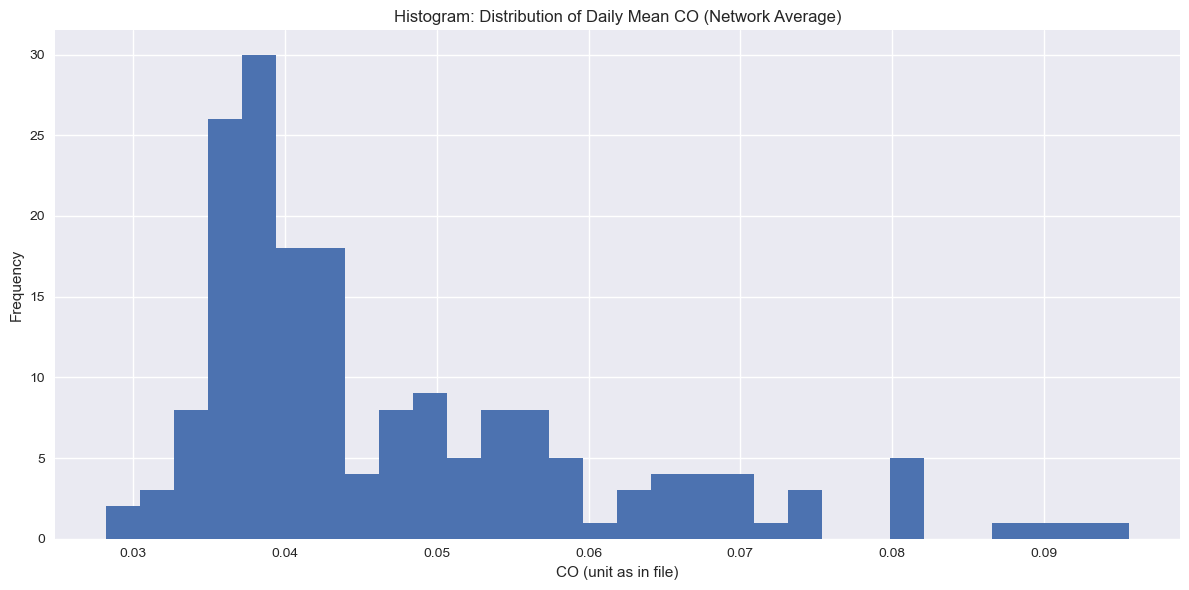

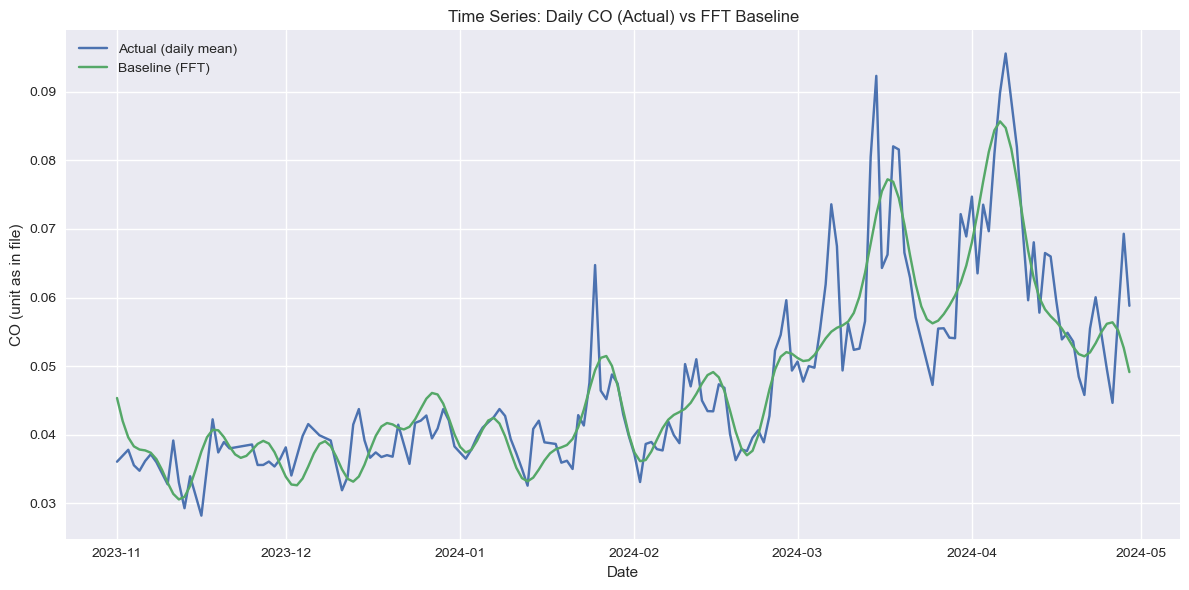

/Users/sakdahomhuan/miniforge3/envs/udfire/lib/python3.13/site-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



Epoch 1: val_loss improved from None to 0.00028, saving model to best_co_lstm.h5



Epoch 2: val_loss improved from 0.00028 to 0.00013, saving model to best_co_lstm.h5



Epoch 3: val_loss did not improve from 0.00013

Epoch 4: val_loss improved from 0.00013 to 0.00011, saving model to best_co_lstm.h5



Epoch 5: val_loss improved from 0.00011 to 0.00011, saving model to best_co_lstm.h5


...


Epoch 30: ReduceLROnPlateau reducing learning rate to 7.812500371073838e-06.

Epoch 30: val_loss improved from 0.00009 to 0.00009, saving model to best_co_lstm.h5



Epoch 31: val_loss improved from 0.00009 to 0.00009, saving model to best_co_lstm.h5



Epoch 32: val_loss did not improve from 0.00009

Epoch 33: val_loss improved from 0.00009 to 0.00009, saving model to best_co_lstm.h5



Epoch 34: ReduceLROnPlateau reducing learning rate to 3.906250185536919e-06.

Epoch 34: val_loss did not improve from 0.00009

Epoch 35: val_loss did not improve from 0.00009

Epoch 36: val_loss improved from 0.00009 to 0.00009, saving model to best_co_lstm.h5



Epoch 37: val_loss did not improve from 0.00009

Epoch 38: ReduceLROnPlateau reducing learning rate to 1.9531250927684596e-06.

Epoch 38: val_loss did not improve from 0.00009

Epoch 39: val_loss did not improve from 0.00009

Epoch 40: val_loss did not improve from 0.00009

Epoch 41: val_loss did not improve from 0.00009

Epoch 42: ReduceLROnPlateau reducing learning rate to 1e-06.

Epoch 42: val_loss did not improve from 0.00009

Epoch 43: val_loss did not improve from 0.00009

Epoch 44: val_loss did not improve from 0.00009
Epoch 44: early stopping
Restoring model weights from the end of the best epoch: 36.
=== Test Set Performance ===
RMSE: 0.009311
MAE : 0.006550
R^2 : 0.584933


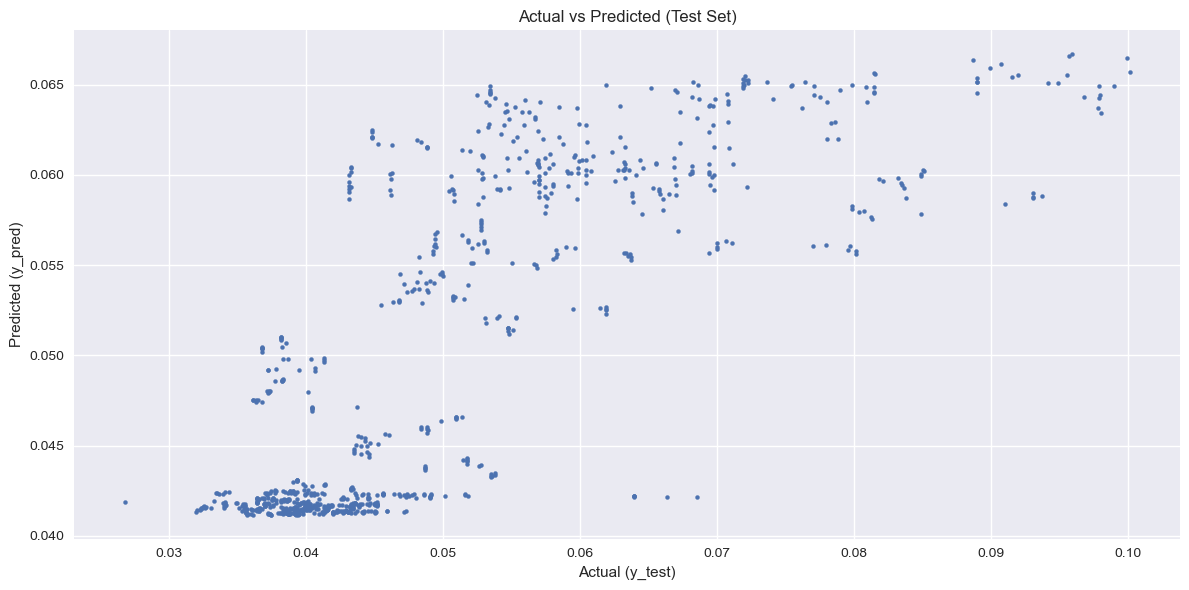

Model saved at: best_co_lstm.h5


Loaded model successfully for 7-day inference.


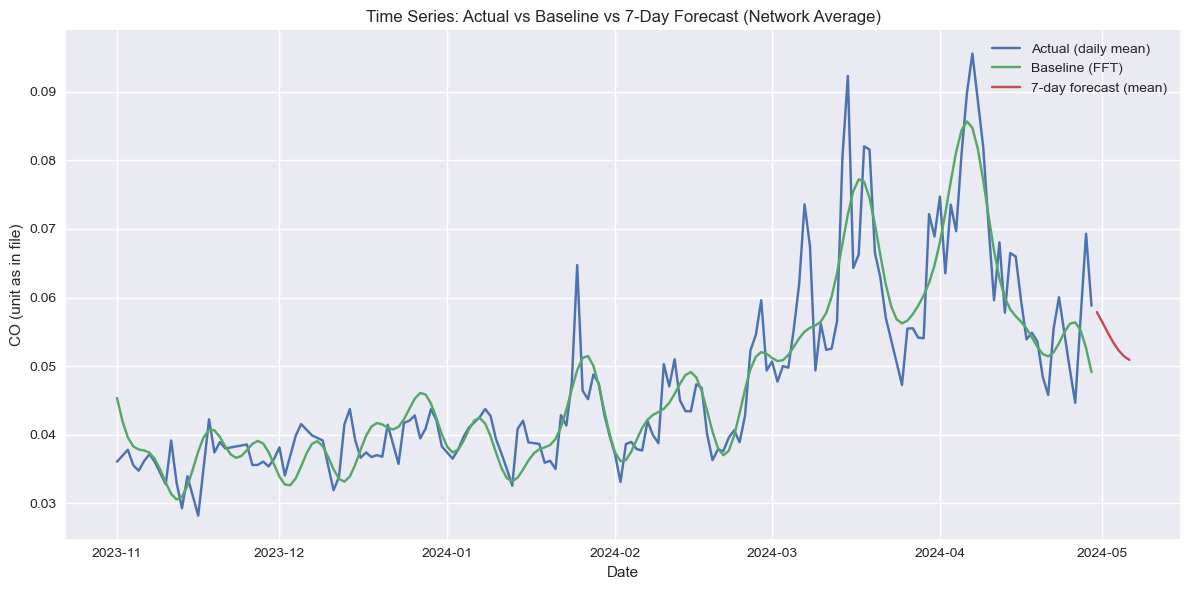

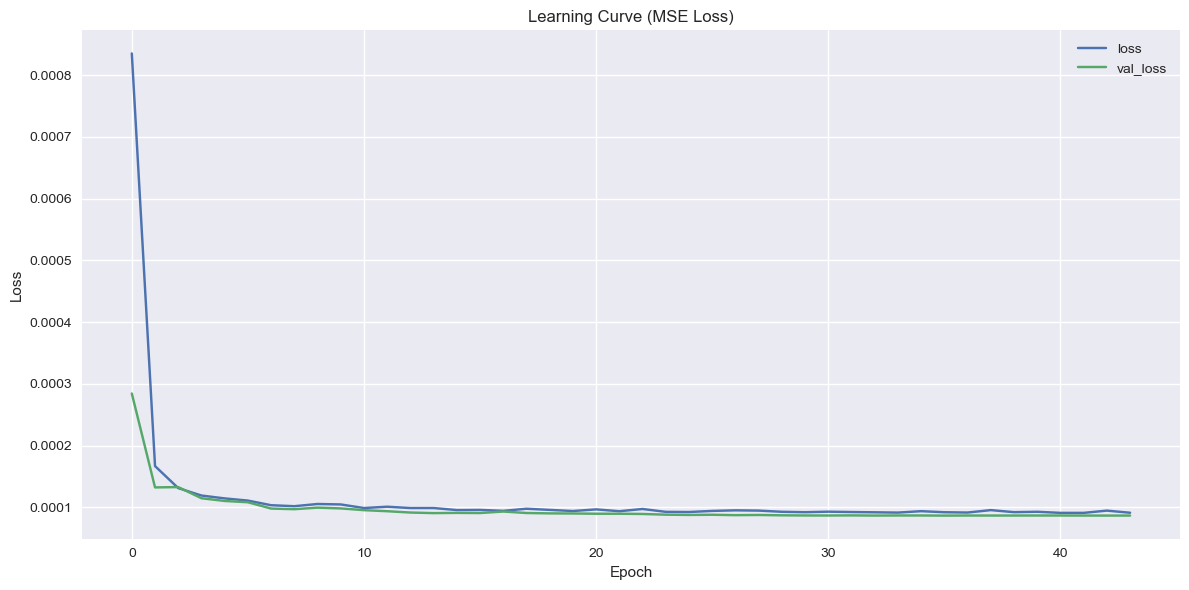

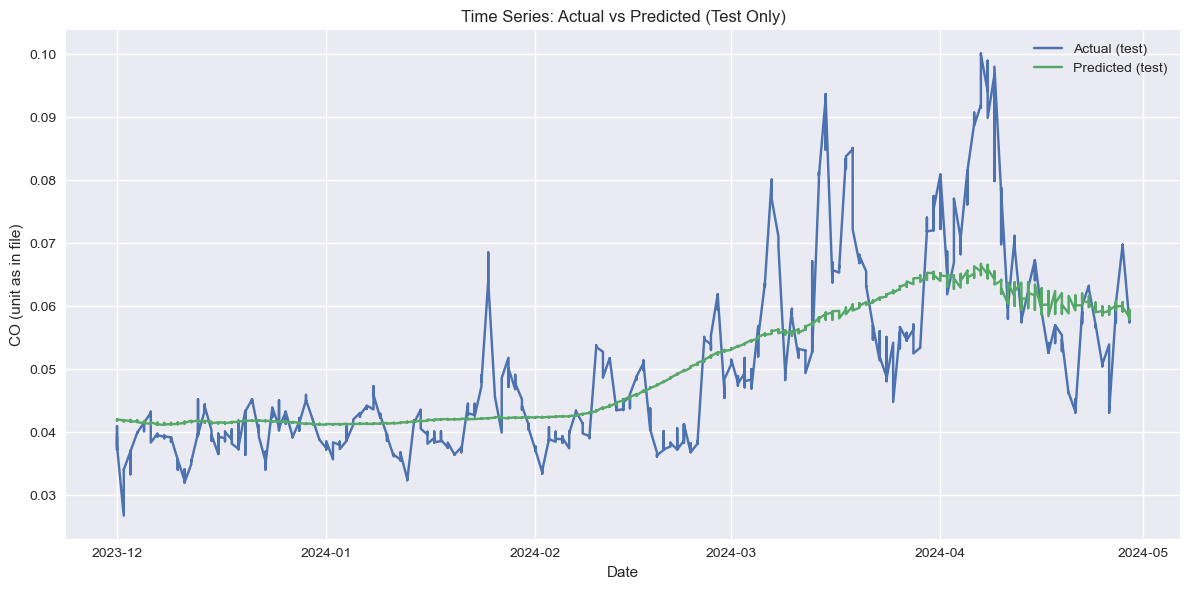

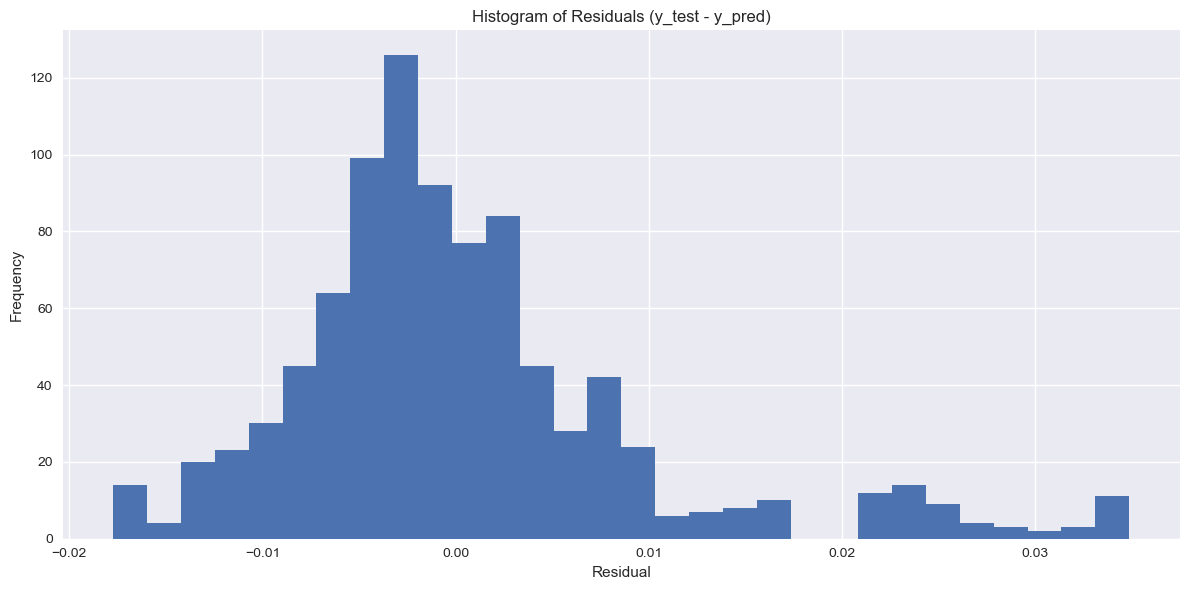

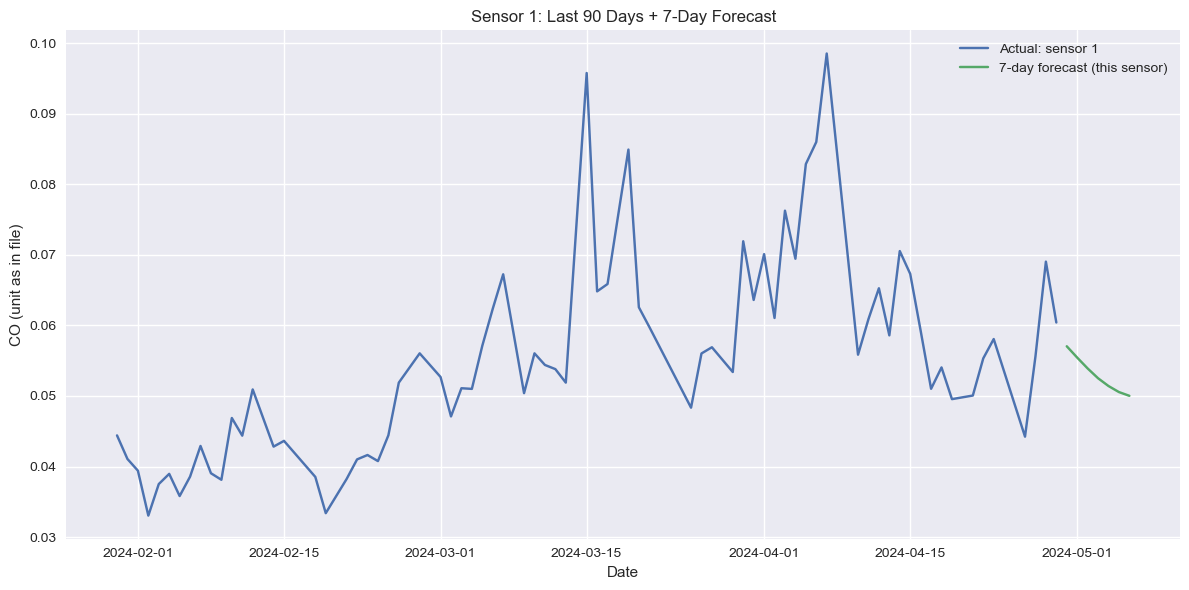

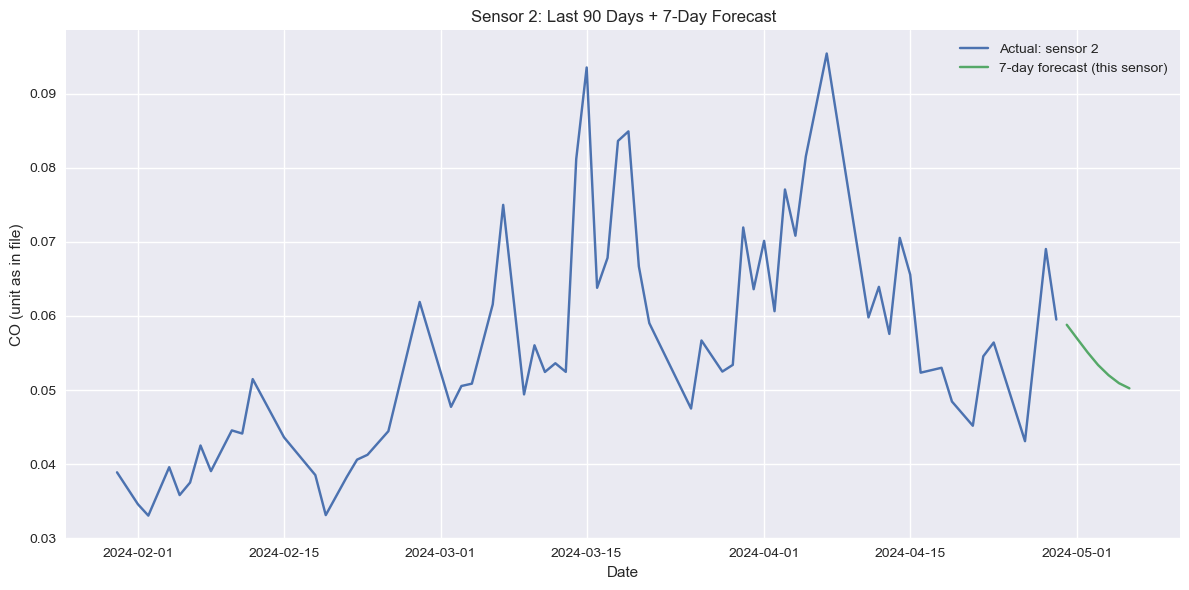

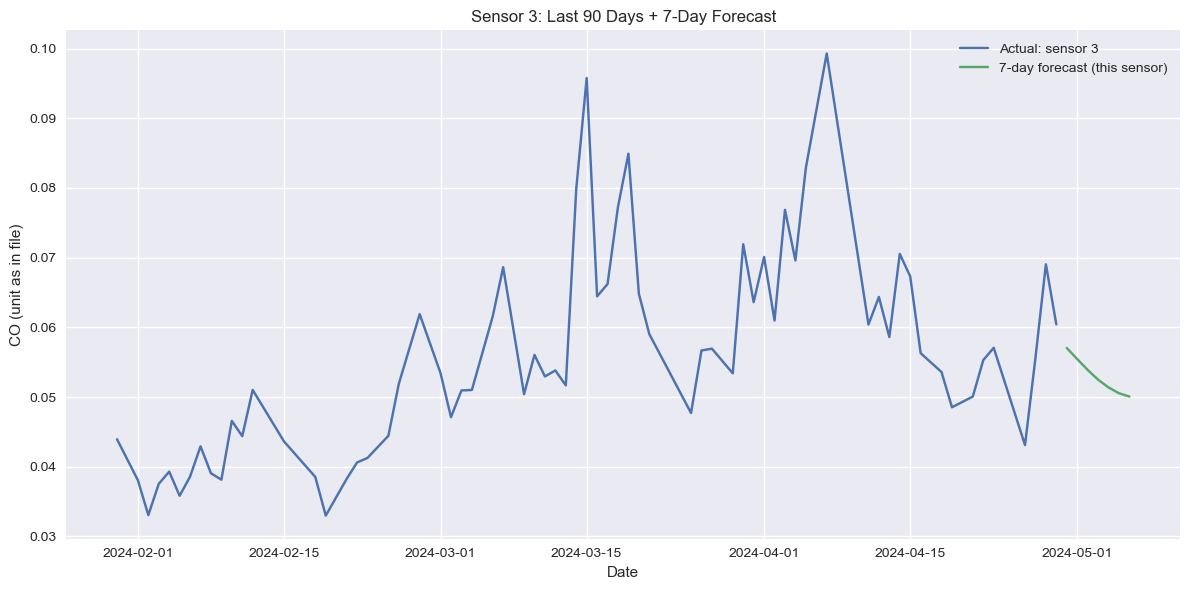

In [13]:
# -*- coding: utf-8 -*-
# CO 7-day Forecast — English chart labels

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import timedelta

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import tensorflow as tf
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Dense, Dropout, Bidirectional, LSTM
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras import backend as K

# -----------------------------
# 1) การเตรียมข้อมูล
# -----------------------------
CSV_PATH = "CO_hex30_urban.csv"

df = pd.read_csv(CSV_PATH)
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values(['id', 'date']).reset_index(drop=True)

def time_interpolate_per_sensor(group):
    g = group.set_index('date').sort_index()
    g['CO'] = g['CO'].interpolate(method='time', limit_direction='both')
    return g.reset_index()

df = df.groupby('id', group_keys=False).apply(time_interpolate_per_sensor)

# -----------------------------
# 2) การวิเคราะห์ข้อมูลเบื้องต้น
# -----------------------------
daily_mean = df.groupby('date', as_index=False)['CO'].mean().rename(columns={'CO':'CO_daily_mean'})

# Histogram — EN labels
plt.style.use('seaborn-v0_8')

plt.figure(figsize=(12, 6))
plt.hist(daily_mean['CO_daily_mean'].dropna().values, bins=30)
plt.title('Histogram: Distribution of Daily Mean CO (Network Average)')
plt.xlabel('CO (unit as in file)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

def fourier_baseline(y, top_k=10):
    y = pd.Series(y).interpolate().bfill().ffill().values
    n = len(y)
    f = np.fft.rfft(y)
    power = np.abs(f)
    idx_sorted = np.argsort(power)[::-1]
    keep = set([0])
    cnt = 0
    for i in idx_sorted:
        if i == 0: 
            continue
        keep.add(i); cnt += 1
        if cnt >= top_k: break
    f_filtered = np.zeros_like(f)
    for i in keep:
        f_filtered[i] = f[i]
    return np.fft.irfft(f_filtered, n=n)

daily_mean = daily_mean.sort_values('date').reset_index(drop=True)
daily_mean['baseline'] = fourier_baseline(daily_mean['CO_daily_mean'].values, top_k=10)

# Time series with baseline — EN labels
plt.figure(figsize=(12, 6))
plt.plot(daily_mean['date'], daily_mean['CO_daily_mean'], label='Actual (daily mean)')
plt.plot(daily_mean['date'], daily_mean['baseline'], label='Baseline (FFT)')
plt.title('Time Series: Daily CO (Actual) vs FFT Baseline')
plt.xlabel('Date')
plt.ylabel('CO (unit as in file)')
plt.legend()
plt.tight_layout()
plt.show()

# -----------------------------
# 3) การเตรียมข้อมูลสำหรับโมเดล
# -----------------------------
df = df.merge(daily_mean[['date','baseline']], on='date', how='left')
df['CO_deseason'] = df['CO'] - df['baseline']

df['doy'] = df['date'].dt.dayofyear
df['sin_doy'] = np.sin(2 * np.pi * df['doy'] / 365.25)
df['cos_doy'] = np.cos(2 * np.pi * df['doy'] / 365.25)

id_min, id_max = df['id'].min(), df['id'].max()
df['id_norm'] = (df['id'] - id_min) / (id_max - id_min + 1e-9)

features = ['CO_deseason', 'sin_doy', 'cos_doy', 'id_norm']
target = 'CO'
df = df.sort_values(['id','date']).reset_index(drop=True)
data_all = df[features + ['date','id', target]].copy()

def create_sequences_panel(data, seq_len=30):
    X_list, y_list, date_list, id_list = [], [], [], []
    for sid, grp in data.groupby('id'):
        grp = grp.sort_values('date').reset_index(drop=True)
        feat_values = grp[features].values
        y_values = grp[target].values
        dates = grp['date'].values
        for i in range(len(grp) - seq_len):
            X_list.append(feat_values[i:i+seq_len])
            y_list.append(y_values[i+seq_len])
            date_list.append(dates[i+seq_len])
            id_list.append(sid)
    X = np.array(X_list)
    y = np.array(y_list)
    meta_dates = np.array(date_list)
    meta_ids = np.array(id_list)
    return X, y, meta_dates, meta_ids

SEQ_LEN = 30
X_raw, y_raw, y_dates, y_ids = create_sequences_panel(data_all, seq_len=SEQ_LEN)

scaler = MinMaxScaler()
n_features = X_raw.shape[-1]
X_2d = X_raw.reshape(-1, n_features)
X_scaled = scaler.fit_transform(X_2d).reshape(X_raw.shape)

n_total = len(X_scaled)
n_train = int(n_total * 0.8)
X_train, y_train = X_scaled[:n_train], y_raw[:n_train]
X_test,  y_test  = X_scaled[n_train:], y_raw[n_train:]

# -----------------------------
# 4) การสร้างและฝึกแบบจำลอง
# -----------------------------
def r2_metric(y_true, y_pred):
    ss_res = K.sum(K.square(y_true - y_pred))
    ss_tot = K.sum(K.square(y_true - K.mean(y_true)))
    return 1.0 - ss_res / (ss_tot + K.epsilon())

tf.keras.utils.set_random_seed(42)

model = Sequential([
    Bidirectional(LSTM(64, return_sequences=True), input_shape=(SEQ_LEN, n_features)),
    Dropout(0.3),
    Bidirectional(LSTM(32, return_sequences=False)),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(1, activation='linear')
])

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
              loss='mse',
              metrics=[r2_metric])

checkpoint_path = "best_co_lstm.h5"
cbs = [
    EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, min_lr=1e-6, verbose=1),
    ModelCheckpoint(filepath=checkpoint_path, monitor='val_loss', save_best_only=True, verbose=1)
]

history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=60,
    batch_size=64,
    callbacks=cbs,
    verbose=0
)

# -----------------------------
# 5) การประเมินแบบจำลอง
# -----------------------------
y_pred = model.predict(X_test, verbose=0).reshape(-1)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae  = mean_absolute_error(y_test, y_pred)
r2   = r2_score(y_test, y_pred)

print("=== Test Set Performance ===")
print(f"RMSE: {rmse:.6f}")
print(f"MAE : {mae:.6f}")
print(f"R^2 : {r2:.6f}")

# Scatter — EN labels
plt.figure(figsize=(12, 6))
plt.scatter(y_test, y_pred, s=8)
plt.xlabel('Actual (y_test)')
plt.ylabel('Predicted (y_pred)')
plt.title('Actual vs Predicted (Test Set)')
plt.tight_layout()
plt.show()

# -----------------------------
# 6) การพยากรณ์ 7 วันถัดไป + บันทึกโมเดล
# -----------------------------
model.save(checkpoint_path, include_optimizer=False)
print(f"Model saved at: {checkpoint_path}")

id_min, id_max = df['id'].min(), df['id'].max()

def forecast_next_7_days_per_sensor(original_df, scaler, SEQ_LEN=30):
    results = []
    last_date_all = original_df['date'].max()
    future_dates = [last_date_all + timedelta(days=i) for i in range(1, 8)]

    for sid, grp in original_df.groupby('id'):
        grp = grp.sort_values('date').reset_index(drop=True)
        if len(grp) < SEQ_LEN:
            continue

        feat = grp[features].values.astype('float32')
        last_seq = feat[-SEQ_LEN:].copy()
        seq_scaled = scaler.transform(last_seq)

        preds = []
        id_norm_val = (sid - id_min) / (id_max - id_min + 1e-9)
        baseline_last = grp['baseline'].iloc[-1]
        last_date = grp['date'].iloc[-1]
        rolling_window = seq_scaled.copy()

        for step in range(7):
            x_input = rolling_window.reshape(1, SEQ_LEN, len(features))
            yhat = model.predict(x_input, verbose=0).reshape(-1)[0]
            preds.append(yhat)

            next_day = last_date + timedelta(days=step+1)
            doy = pd.Timestamp(next_day).dayofyear
            sin_doy = np.sin(2 * np.pi * doy / 365.25)
            cos_doy = np.cos(2 * np.pi * doy / 365.25)
            co_deseason_next = yhat - baseline_last

            next_feat = np.array([[co_deseason_next, sin_doy, cos_doy, id_norm_val]], dtype='float32')
            next_feat_scaled = scaler.transform(next_feat)
            rolling_window = np.vstack([rolling_window[1:], next_feat_scaled])

        results.append(pd.DataFrame({'id': sid, 'date': future_dates, 'CO_forecast': preds}))

    if not results:
        return pd.DataFrame(columns=['id','date','CO_forecast'])
    return pd.concat(results, axis=0, ignore_index=True)

data_all_with_base = data_all.merge(daily_mean[['date','baseline']], on='date', how='left')
forecast_df = forecast_next_7_days_per_sensor(data_all_with_base, scaler, SEQ_LEN=SEQ_LEN)
forecast_daily_mean = (forecast_df.groupby('date', as_index=False)['CO_forecast'].mean()
                       if not forecast_df.empty else pd.DataFrame(columns=['date','CO_forecast']))

# -----------------------------
# 7) การนำไปใช้
# -----------------------------
loaded_model = load_model(checkpoint_path, custom_objects={'r2_metric': r2_metric})
print("Loaded model successfully for 7-day inference.")

# -----------------------------
# 8) การแสดงผลรายงาน — EN labels
# -----------------------------
# Overall time series with forecast

plt.figure(figsize=(12, 6))
plt.plot(daily_mean['date'], daily_mean['CO_daily_mean'], label='Actual (daily mean)')
plt.plot(daily_mean['date'], daily_mean['baseline'], label='Baseline (FFT)')
if not forecast_daily_mean.empty:
    plt.plot(forecast_daily_mean['date'], forecast_daily_mean['CO_forecast'], label='7-day forecast (mean)')
plt.title('Time Series: Actual vs Baseline vs 7-Day Forecast (Network Average)')
plt.xlabel('Date')
plt.ylabel('CO (unit as in file)')
plt.legend()
plt.tight_layout()
plt.show()

# Learning curve
plt.figure(figsize=(12, 6))
plt.plot(history.history['loss'], label='loss')
plt.plot(history.history.get('val_loss', []), label='val_loss')
plt.title('Learning Curve (MSE Loss)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()
plt.show()

# Test-only time series
y_dates_test = y_dates[n_train:]
order = np.argsort(y_dates_test)
plt.figure(figsize=(12, 6))
plt.plot(y_dates_test[order], y_test[order], label='Actual (test)')
plt.plot(y_dates_test[order], y_pred[order], label='Predicted (test)')
plt.title('Time Series: Actual vs Predicted (Test Only)')
plt.xlabel('Date')
plt.ylabel('CO (unit as in file)')
plt.legend()
plt.tight_layout()
plt.show()

# Residual histogram (optional)
residuals = y_test - y_pred
plt.figure(figsize=(12, 6))
plt.hist(residuals, bins=30)
plt.title('Histogram of Residuals (y_test - y_pred)')
plt.xlabel('Residual')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

# Per-sensor examples
unique_ids = sorted(df['id'].unique().tolist())
sample_ids = unique_ids[:3] if len(unique_ids) >= 3 else unique_ids
for sid in sample_ids:
    g = df[df['id'] == sid].sort_values('date')
    g_recent = g[g['date'] >= (g['date'].max() - pd.Timedelta(days=90))]
    f = forecast_df[forecast_df['id'] == sid] if not forecast_df.empty else pd.DataFrame(columns=['date','CO_forecast'])

    plt.figure(figsize=(12, 6))
    plt.plot(g_recent['date'], g_recent['CO'], label=f'Actual: sensor {sid}')
    if not f.empty:
        plt.plot(f['date'], f['CO_forecast'], label='7-day forecast (this sensor)')
    plt.title(f'Sensor {sid}: Last 90 Days + 7-Day Forecast')
    plt.xlabel('Date')
    plt.ylabel('CO (unit as in file)')
    plt.legend()
    plt.tight_layout()
    plt.show()
